# ISeeSnow: Idealized topography — Voellmy — AVAC

This notebook runs one official ISeeSnow case without calibration, writes the required peak-flow-thickness and peak-flow-velocity rasters, and compares them on the supplied grid with participating-model submissions.


## Reproducible environment

The first code cell installs the repository's validation package and Python dependencies into the active kernel. A clean checkout also needs GNU Make and gfortran to compile the selected solver on first use. The pinned official ISeeSnow 1.0 dataset is downloaded automatically on first use.


In [1]:
from pathlib import Path
SEARCH_ROOT = Path.cwd().resolve()
REPOSITORY = next(candidate for candidate in (SEARCH_ROOT, *SEARCH_ROOT.parents) if (candidate / 'validation' / 'pyproject.toml').is_file())
%pip install -q -e {REPOSITORY / 'validation'}


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from avac4qgis_validation import validation_case
case = validation_case('ISeeSnow', 'IdealizedTopo')
CORES = max(1, os.cpu_count() or 1)
case.path


PosixPath('/Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/IdealizedTopo')

In [3]:
from avac4qgis_validation.datasets import ensure_iseesnow
benchmark = ensure_iseesnow()
benchmark


PosixPath('/Users/cmgotelli/Desktop/AVAC-QGIS/validation/_data/ISeeSnow')

## Prescribed benchmark configuration

The supplied 5 m DEM and release polygon are run with $\mu=0.4$, $\xi=2000$ m/s², and 1.5 m release thickness normal to the terrain. No peer-model result is used to select an AVAC parameter. The simulation ceiling is 1200 s and the native state is checked for practical arrest.


In [4]:
CASE_NAME = 'IdealizedTopo'
RESULTS_ROOT = Path(os.environ.get('AVAC_ISEESNOW_RESULTS_ROOT', case.path.parent)).expanduser().resolve()
case.run(case.path.parent / 'run_iseesnow_avac.py', '--case', CASE_NAME, '--workers', CORES, '--spatial-order', 2, '--results-root', RESULTS_ROOT, '--overwrite', cwd=case.path.parent)


Running: /Users/cmgotelli/anaconda3/bin/python /Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/run_iseesnow_avac.py --case IdealizedTopo --workers 8 --spatial-order 2 --results-root /Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow --overwrite
* computational domain x = [997.50, 6002.50] m, nx = 1001
* computational domain y = [-5002.50, -3497.50] m, ny = 301
*** WARNING: Selective output_aux_components not implemented
***          Will output all components of aux
/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/clawpack-v5.14.0/geoclaw/src/python/geoclaw/data.py:199: UserWarning: 
  *** WARNING: topofile specs changed in v5.8.0 -- Flag level info now ignored
  warnings.warn(w, UserWarning)
/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/clawpack-v5.14.0/geoclaw/src/python/geoclaw/data.py:142: UserWarning: 
  *** WARNING: deep_depth parameter ignored as of v5.8.0
  warnings.warn(w, UserWarning)
/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/clawpack-v5.14.0/geoclaw/src/python/geocl

## Run diagnostics and ISeeSnow submission

The summary records volume, duration, practical stop time, numerical controls, solver hash, and generated standard-format files.


In [5]:
import json
summary = json.loads((RESULTS_ROOT / CASE_NAME / 'run_summary.json').read_text(encoding='utf-8'))
summary


{'case': 'IdealizedTopo',
 'cpu_seconds': 1457.705045,
 'wall_seconds': 562.3780556658749,
 'simulation_end_ceiling_seconds': 1200.0,
 'flow_stopped_at_seconds': None,
 'flow_stopped_before_ceiling': False,
 'final_max_speed_mps': 5.318416871613347,
 'speed_limit_mps': 1e+99,
 'spatial_order': 2,
 'limiter': 'vanleer',
 'cfl_target': 0.5,
 'diagnostic_gauge': None,
 'refinement_levels': 1,
 'refinement_ratio': 2,
 'finest_effective_cell_size_m': 5.0,
 'maximum_amr_level': 1,
 'plugin_version': '0.5.14',
 'solver': '/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/src/AVAC/xgeoclaw',
 'solver_sha256': '6e85bee646c3d4730693b70323c7195ca84dc1b6a075d9ea1b803624838310f9',
 'initial_volume_m3': 74908.91343653202,
 'final_volume_m3': 73706.4093708611,
 'signed_final_volume_m3': 73706.4093708611,
 'relative_volume_change': -0.01605288356891949,
 'native_mass_history': '/Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/IdealizedTopo/native_mass_history.csv',
 'pft': '/Users/cmgotelli/Desktop/A

## Direct peer comparison

Only peer fields with exactly matching dimensions, cell size, and cell-center coordinates are included; no shifting, clipping, padding, or resampling is performed.


Running: /Users/cmgotelli/anaconda3/bin/python /Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/compare_iseesnow.py --case IdealizedTopo --results-root /Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow --output-root /Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow
{
  "comparisons": 16,
  "exclusions": 3
}


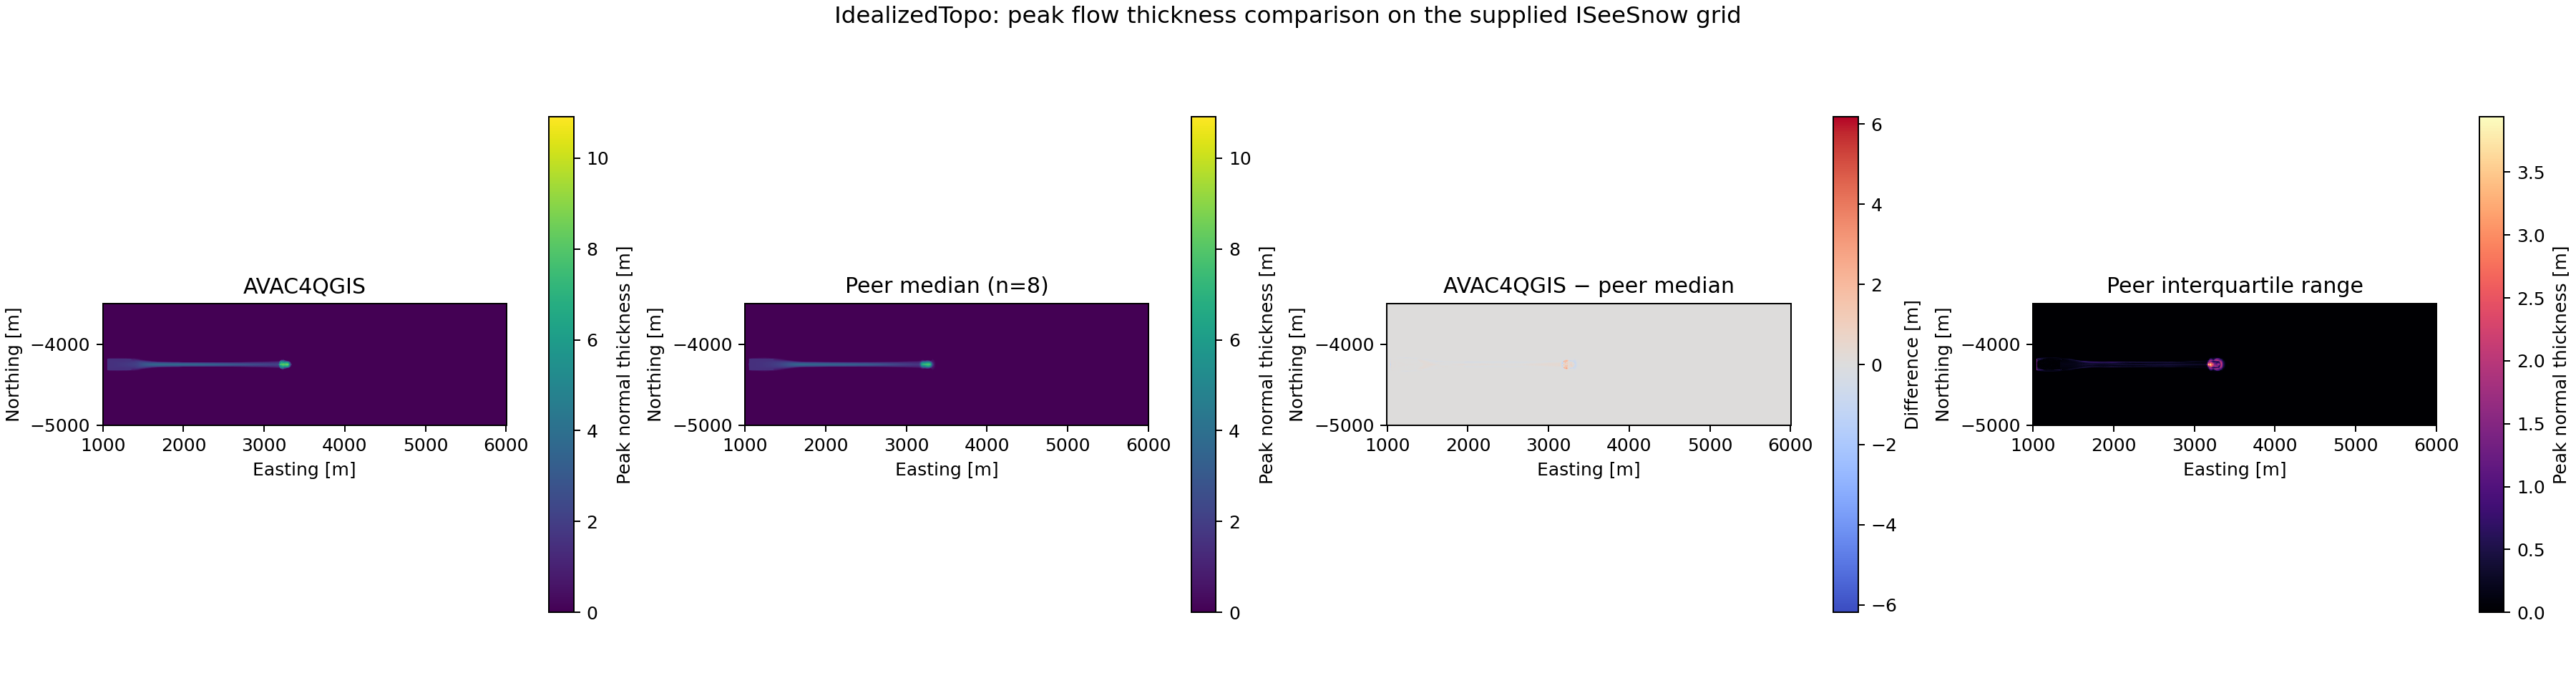

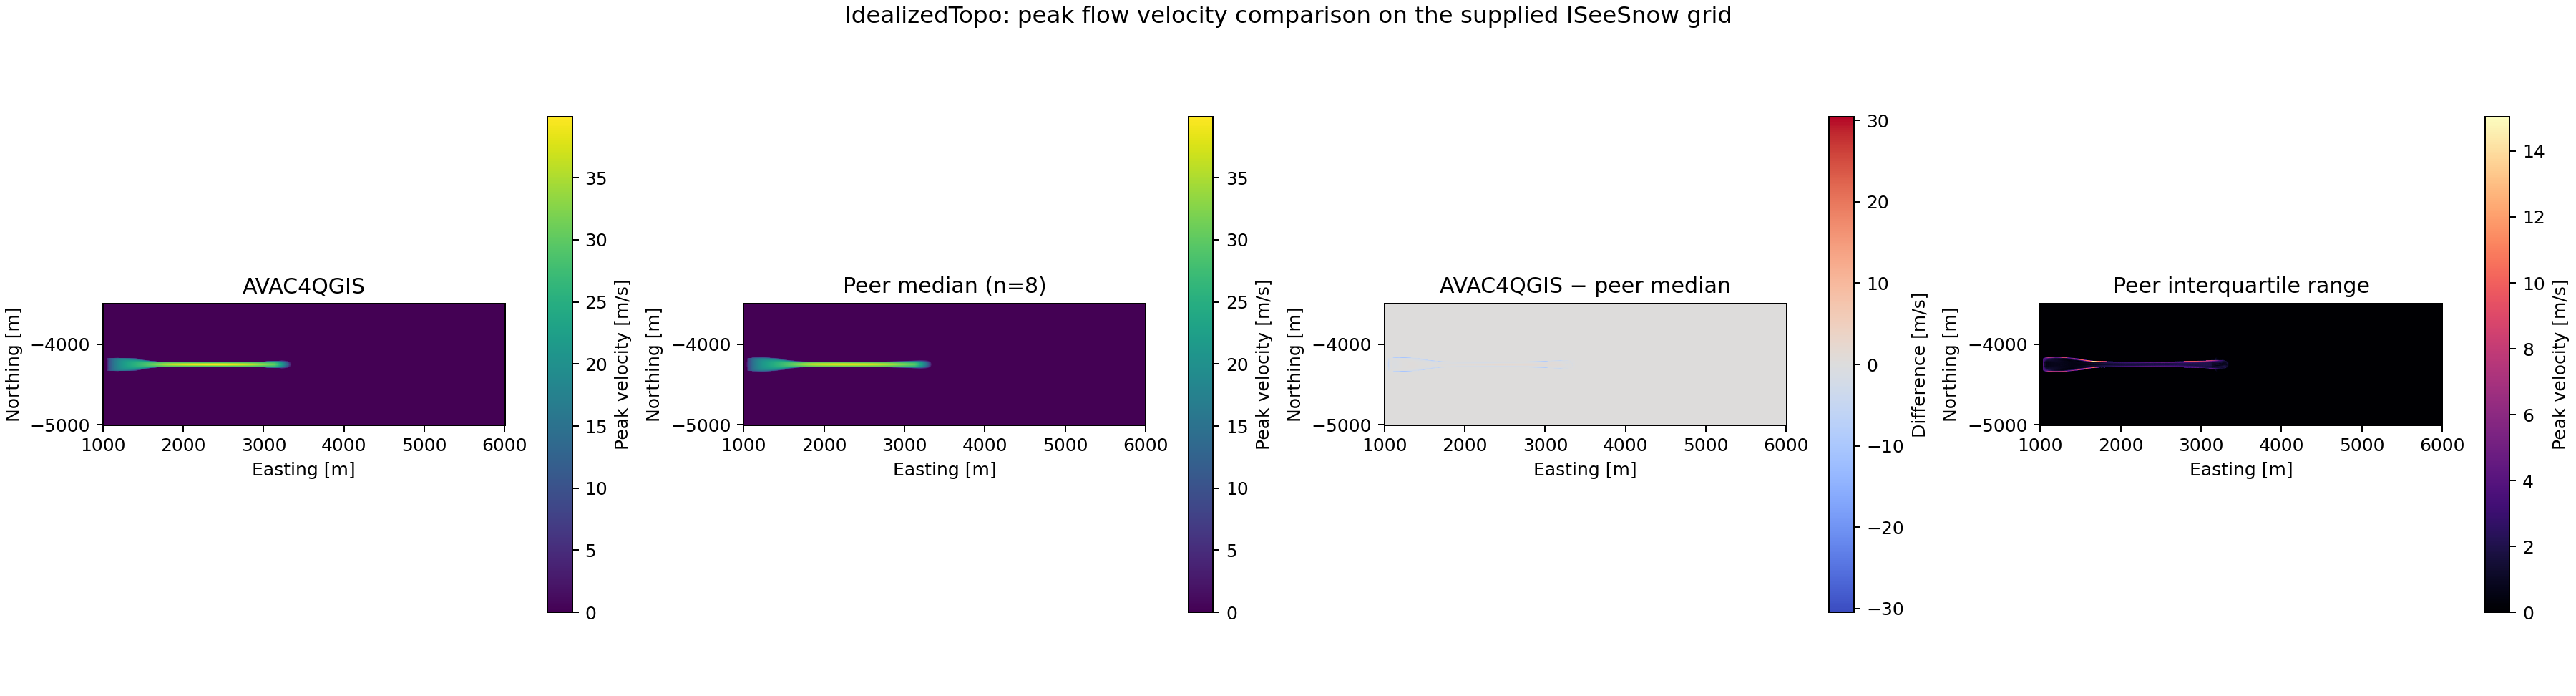

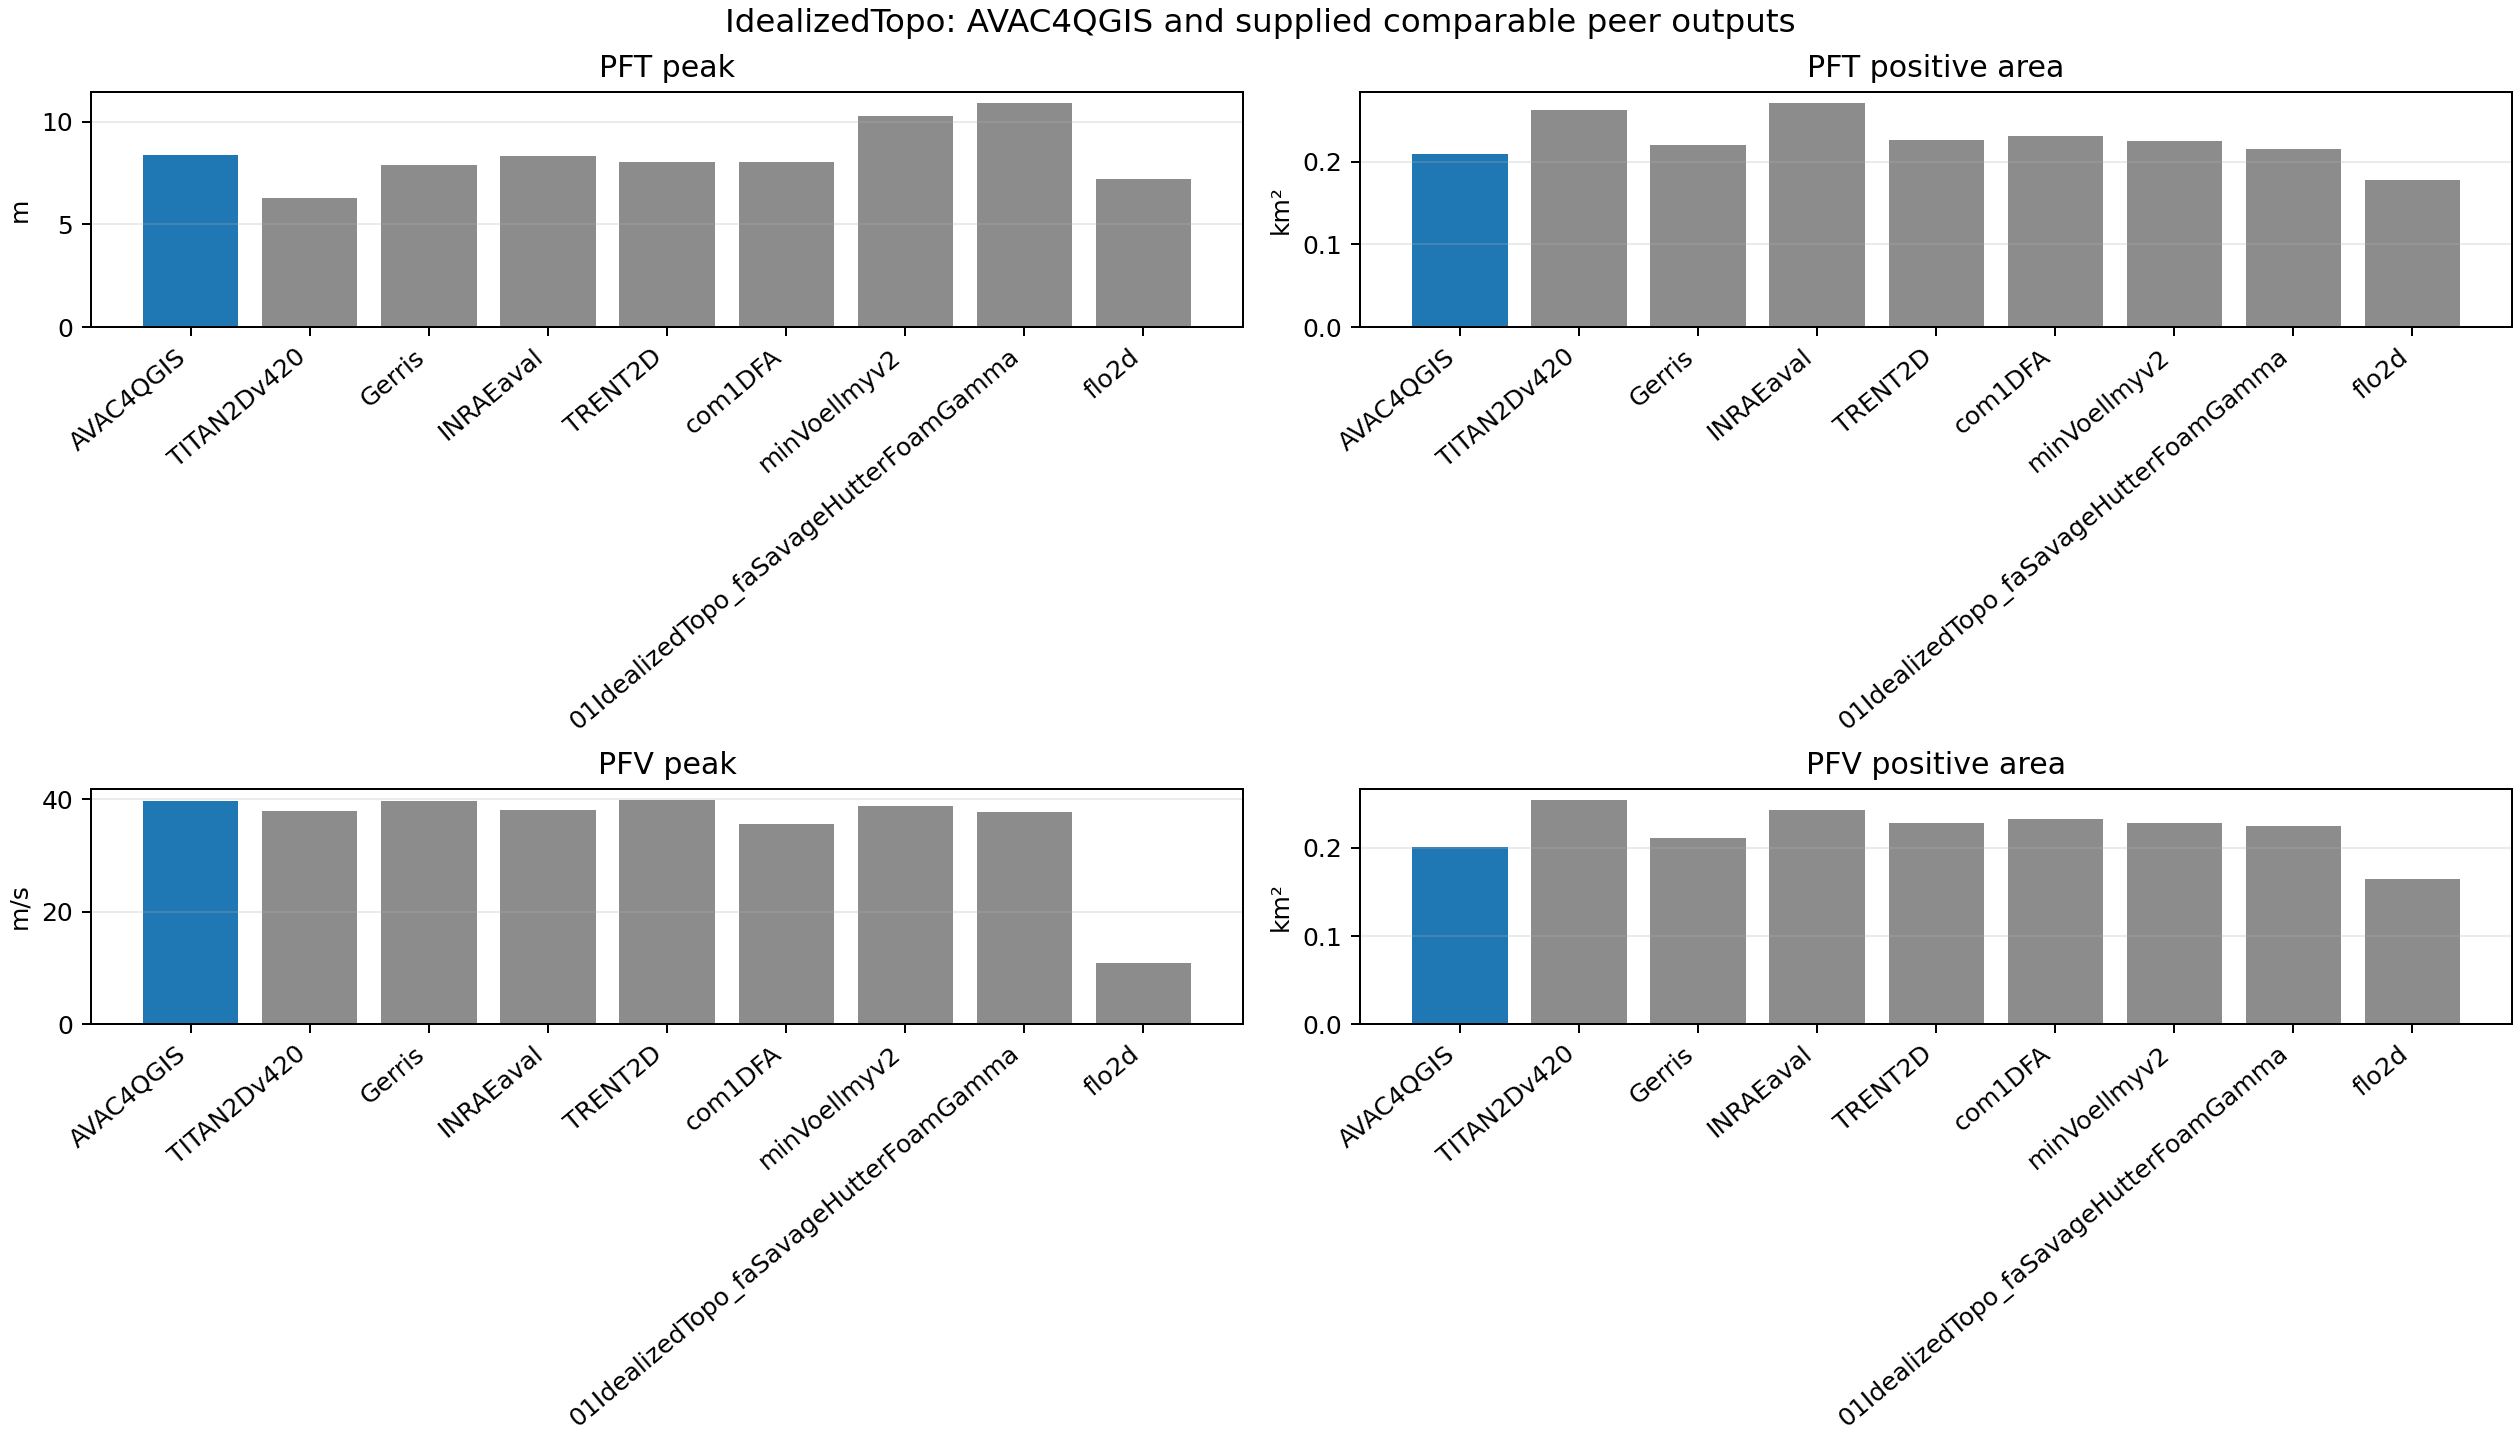

In [6]:
case.run(case.path.parent / 'compare_iseesnow.py', '--case', CASE_NAME, '--results-root', RESULTS_ROOT, '--output-root', RESULTS_ROOT, cwd=case.path.parent)
case.show(RESULTS_ROOT / 'plots' / f'{CASE_NAME}_pft_peer_comparison.png', RESULTS_ROOT / 'plots' / f'{CASE_NAME}_pfv_peer_comparison.png', RESULTS_ROOT / 'plots' / f'{CASE_NAME}_scalar_peer_comparison.png')


## Paper-style idealized-case figures

These panels follow the ISeeSnow paper display conventions while retaining every model's native submitted grid and values.


Running: /Users/cmgotelli/anaconda3/bin/python /Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/reproduce_paper_idealized_voellmy.py
/Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/paper_figures/VoellmyIdealized/Figure_2_style_VoellmyIdealized_PFT_with_AVAC4QGIS.png
/Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/paper_figures/VoellmyIdealized/Figure_3_style_VoellmyIdealized_PFT_0p5m_contours_with_AVAC4QGIS.png
/Users/cmgotelli/Desktop/AVAC-QGIS/validation/ISeeSnow/paper_figures/VoellmyIdealized/Figure_C2_style_VoellmyIdealized_PFV_with_AVAC4QGIS.png


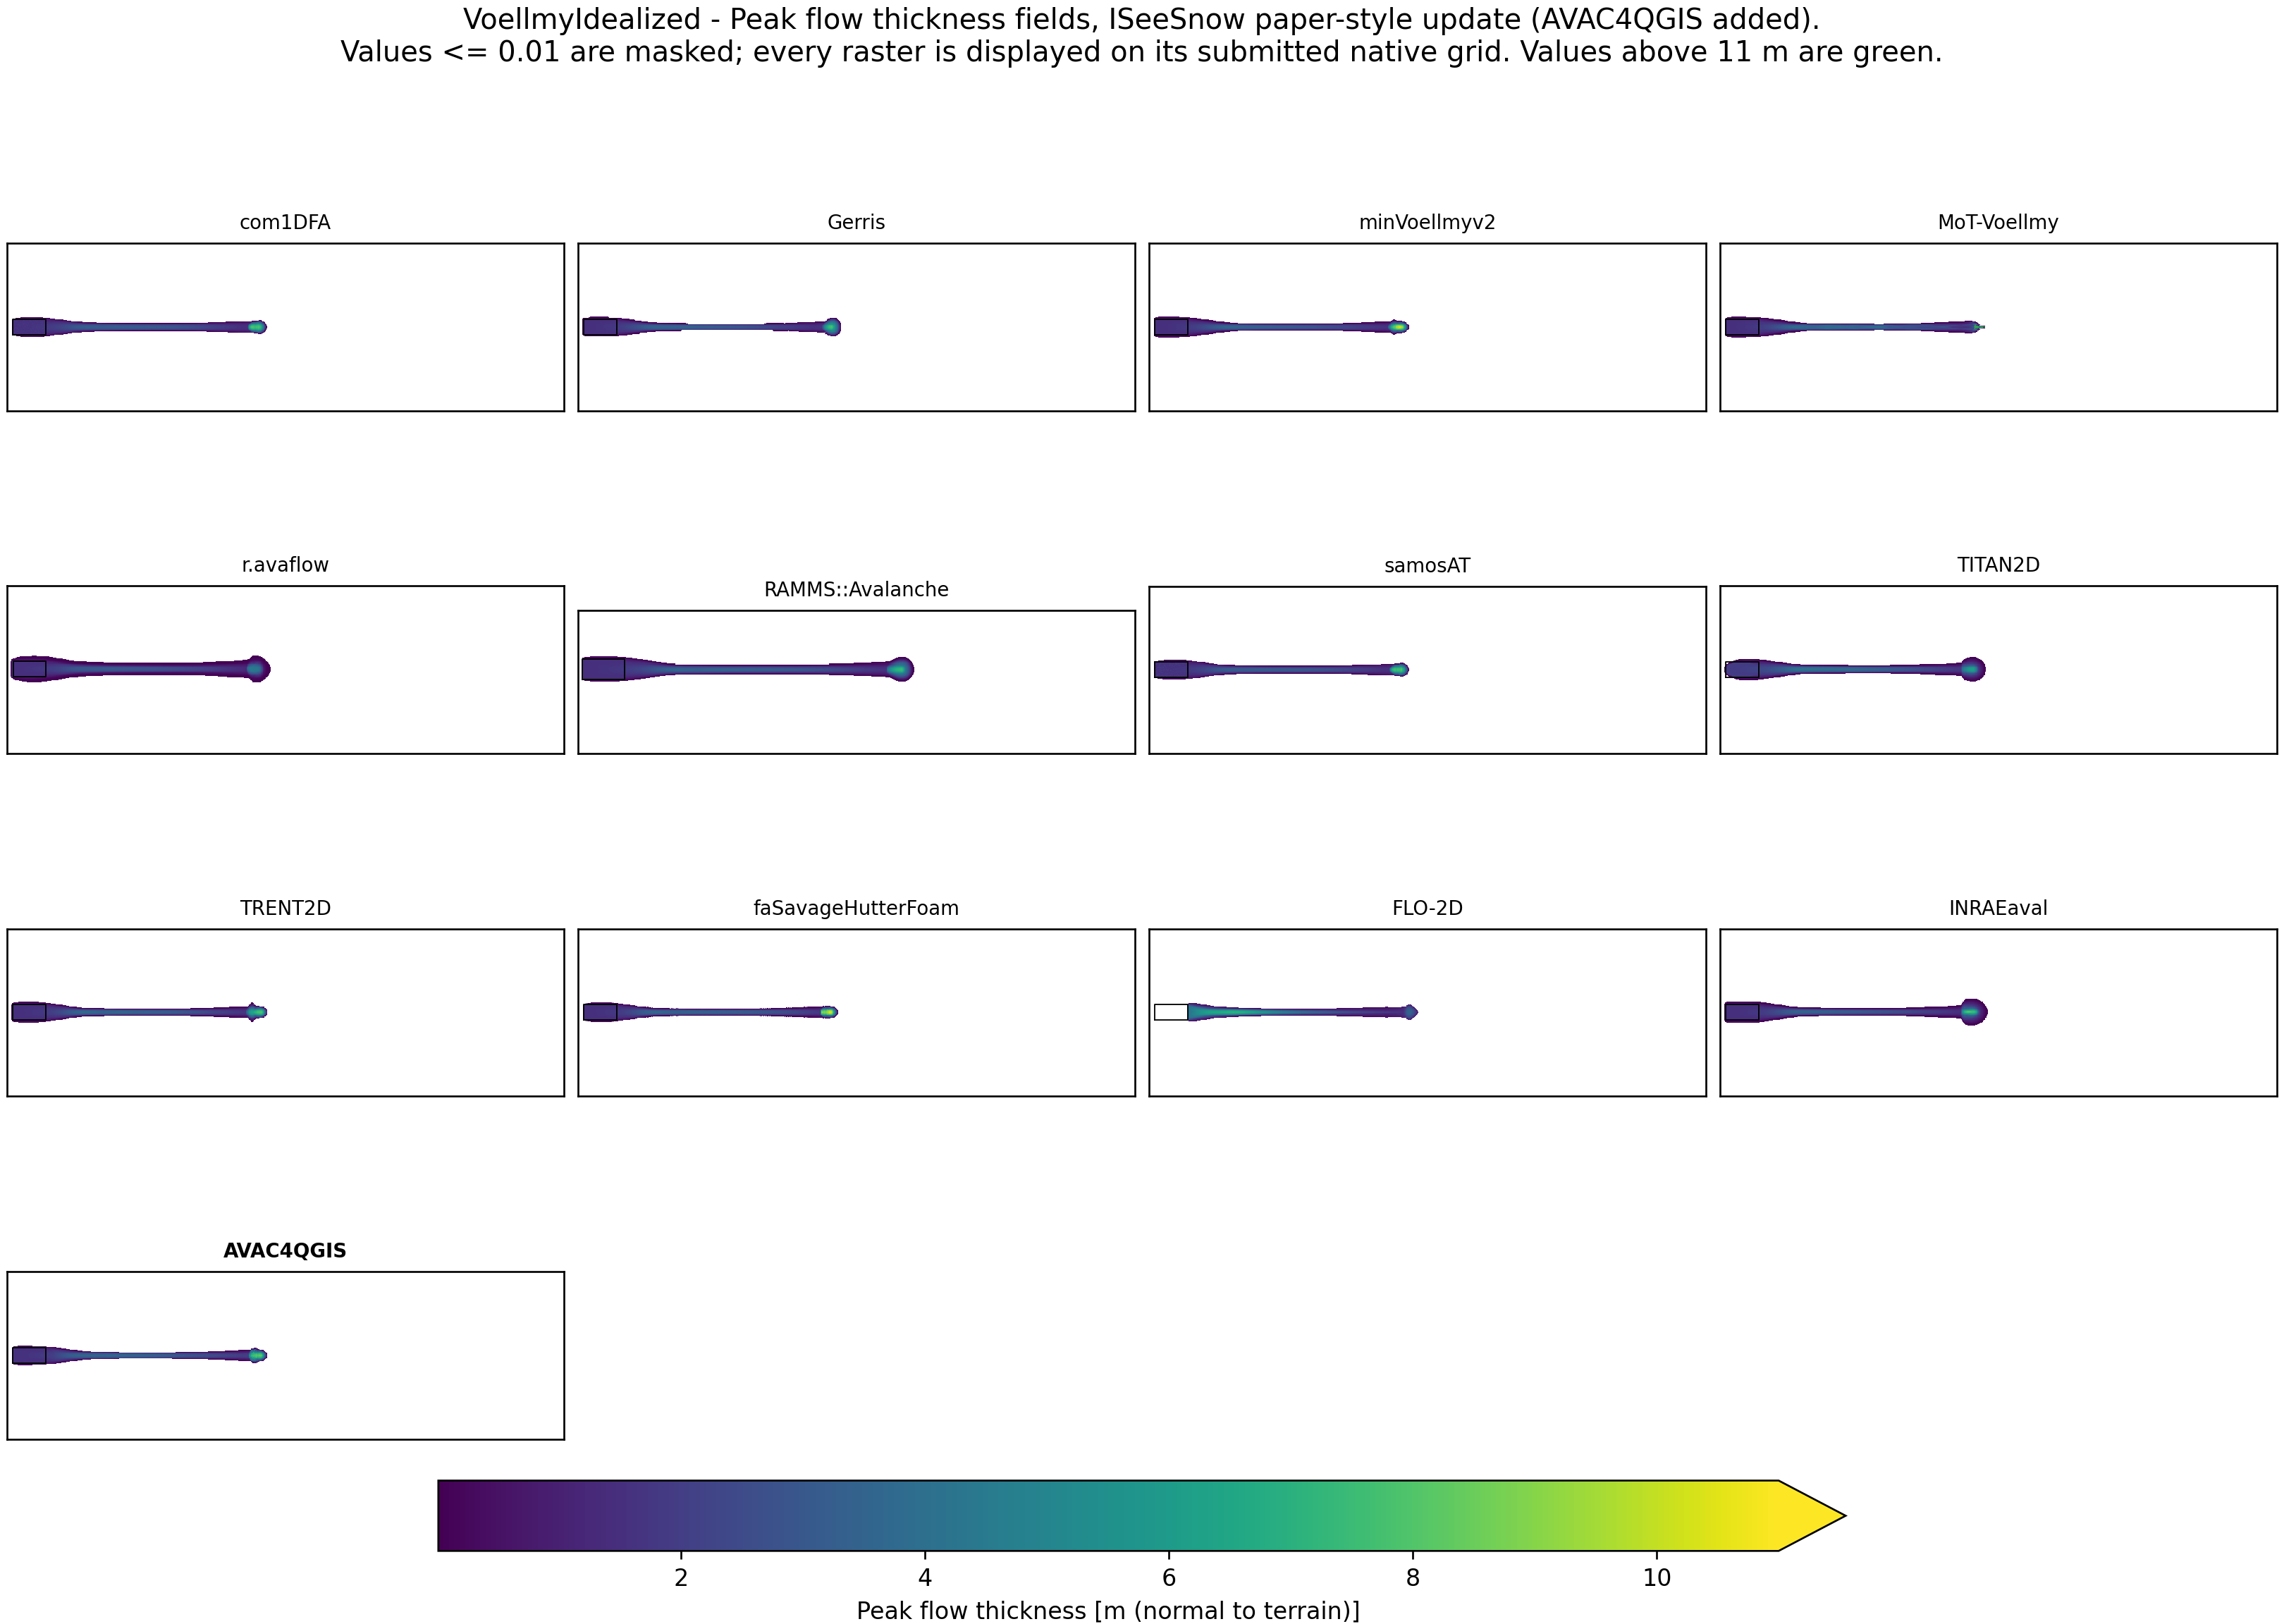

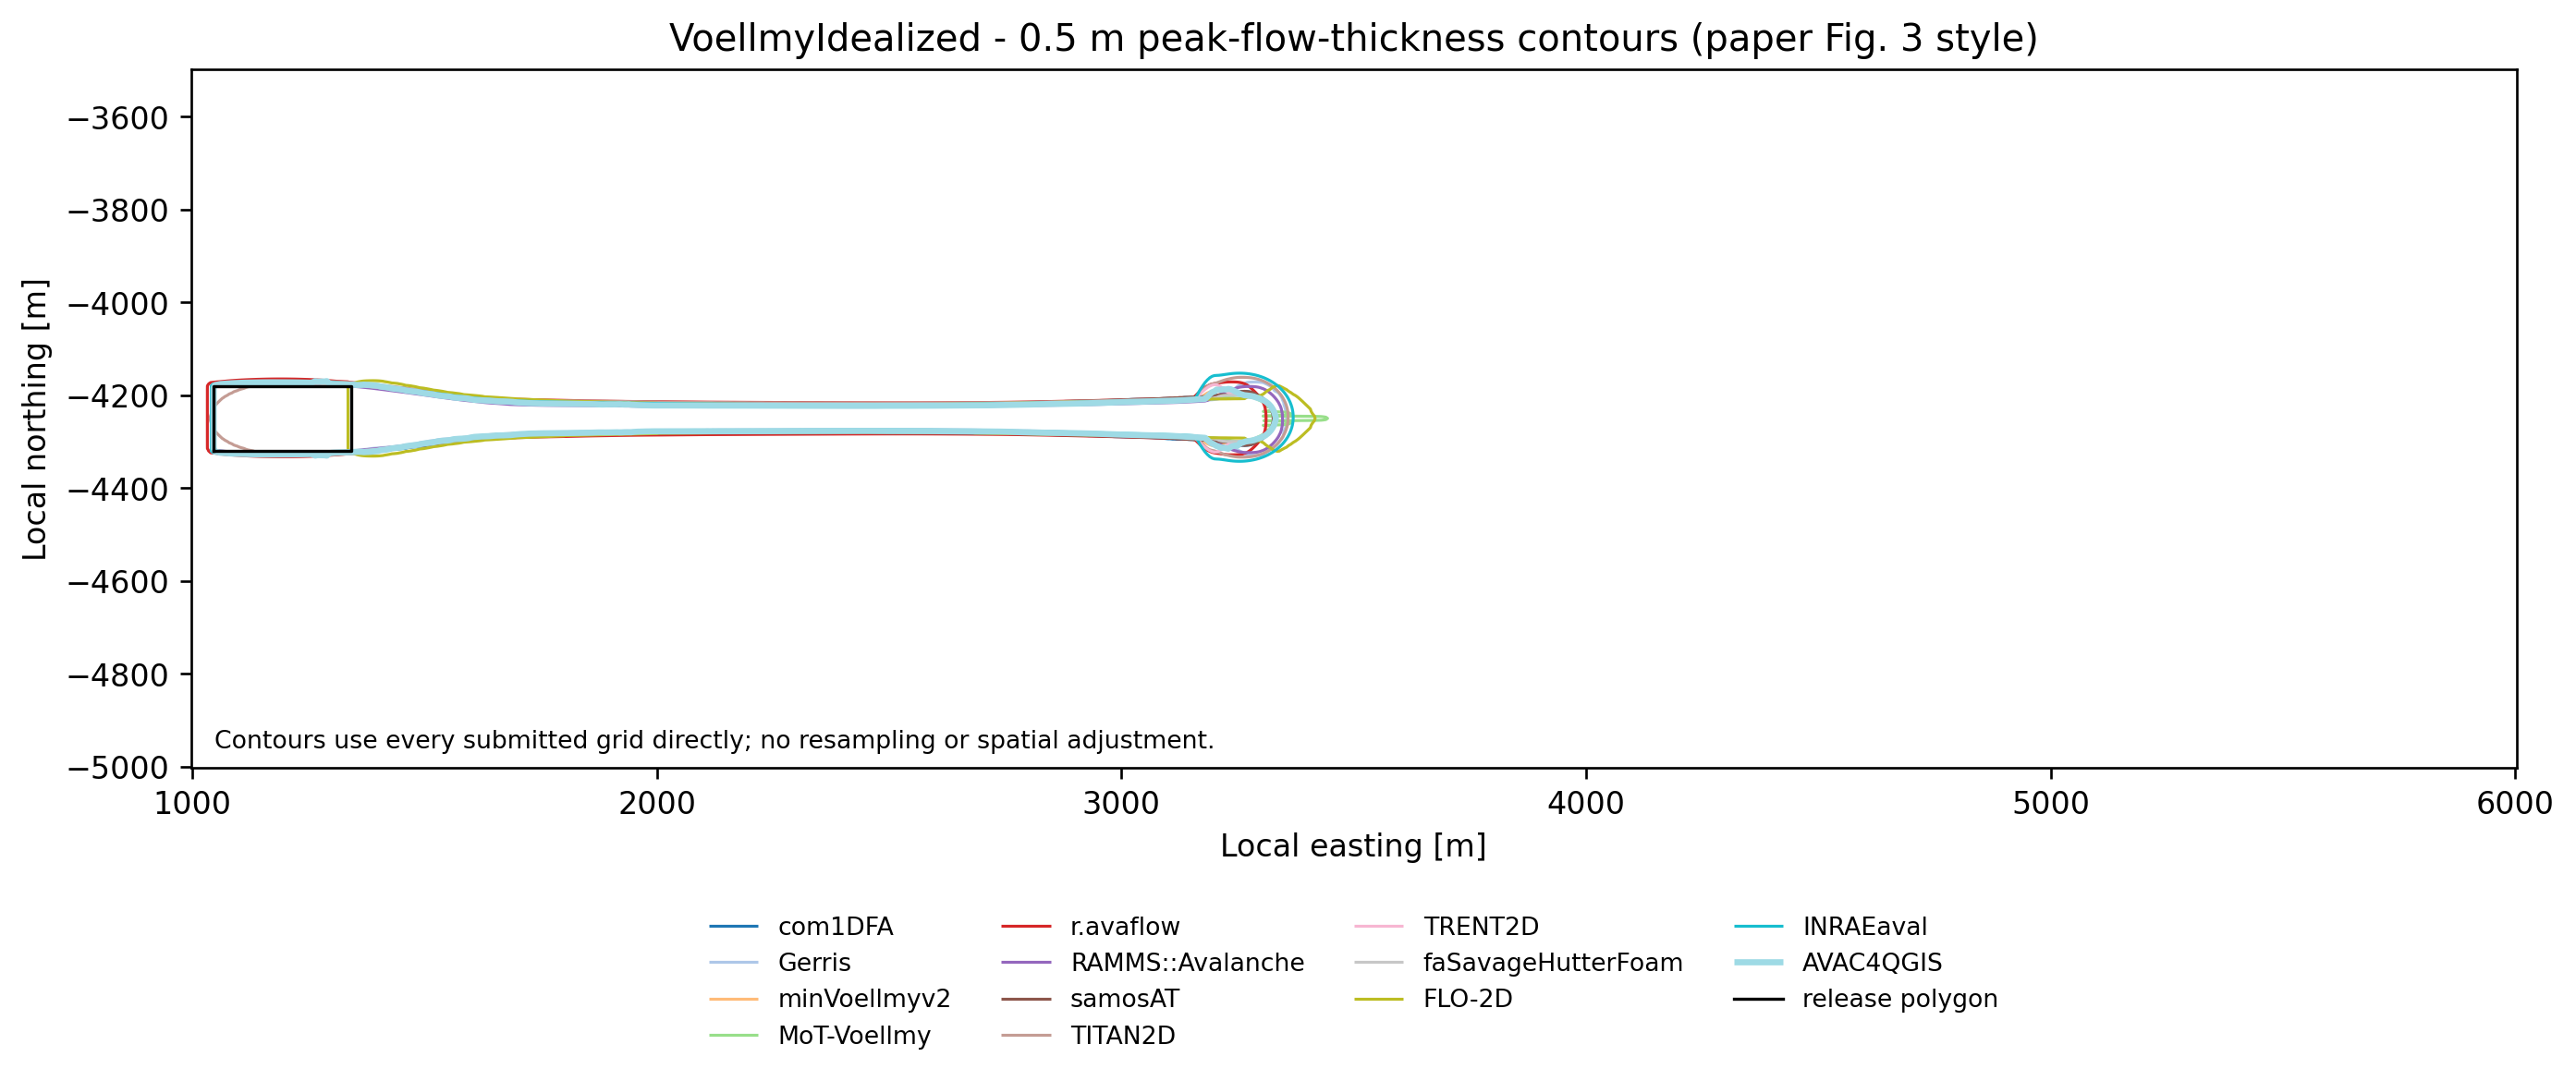

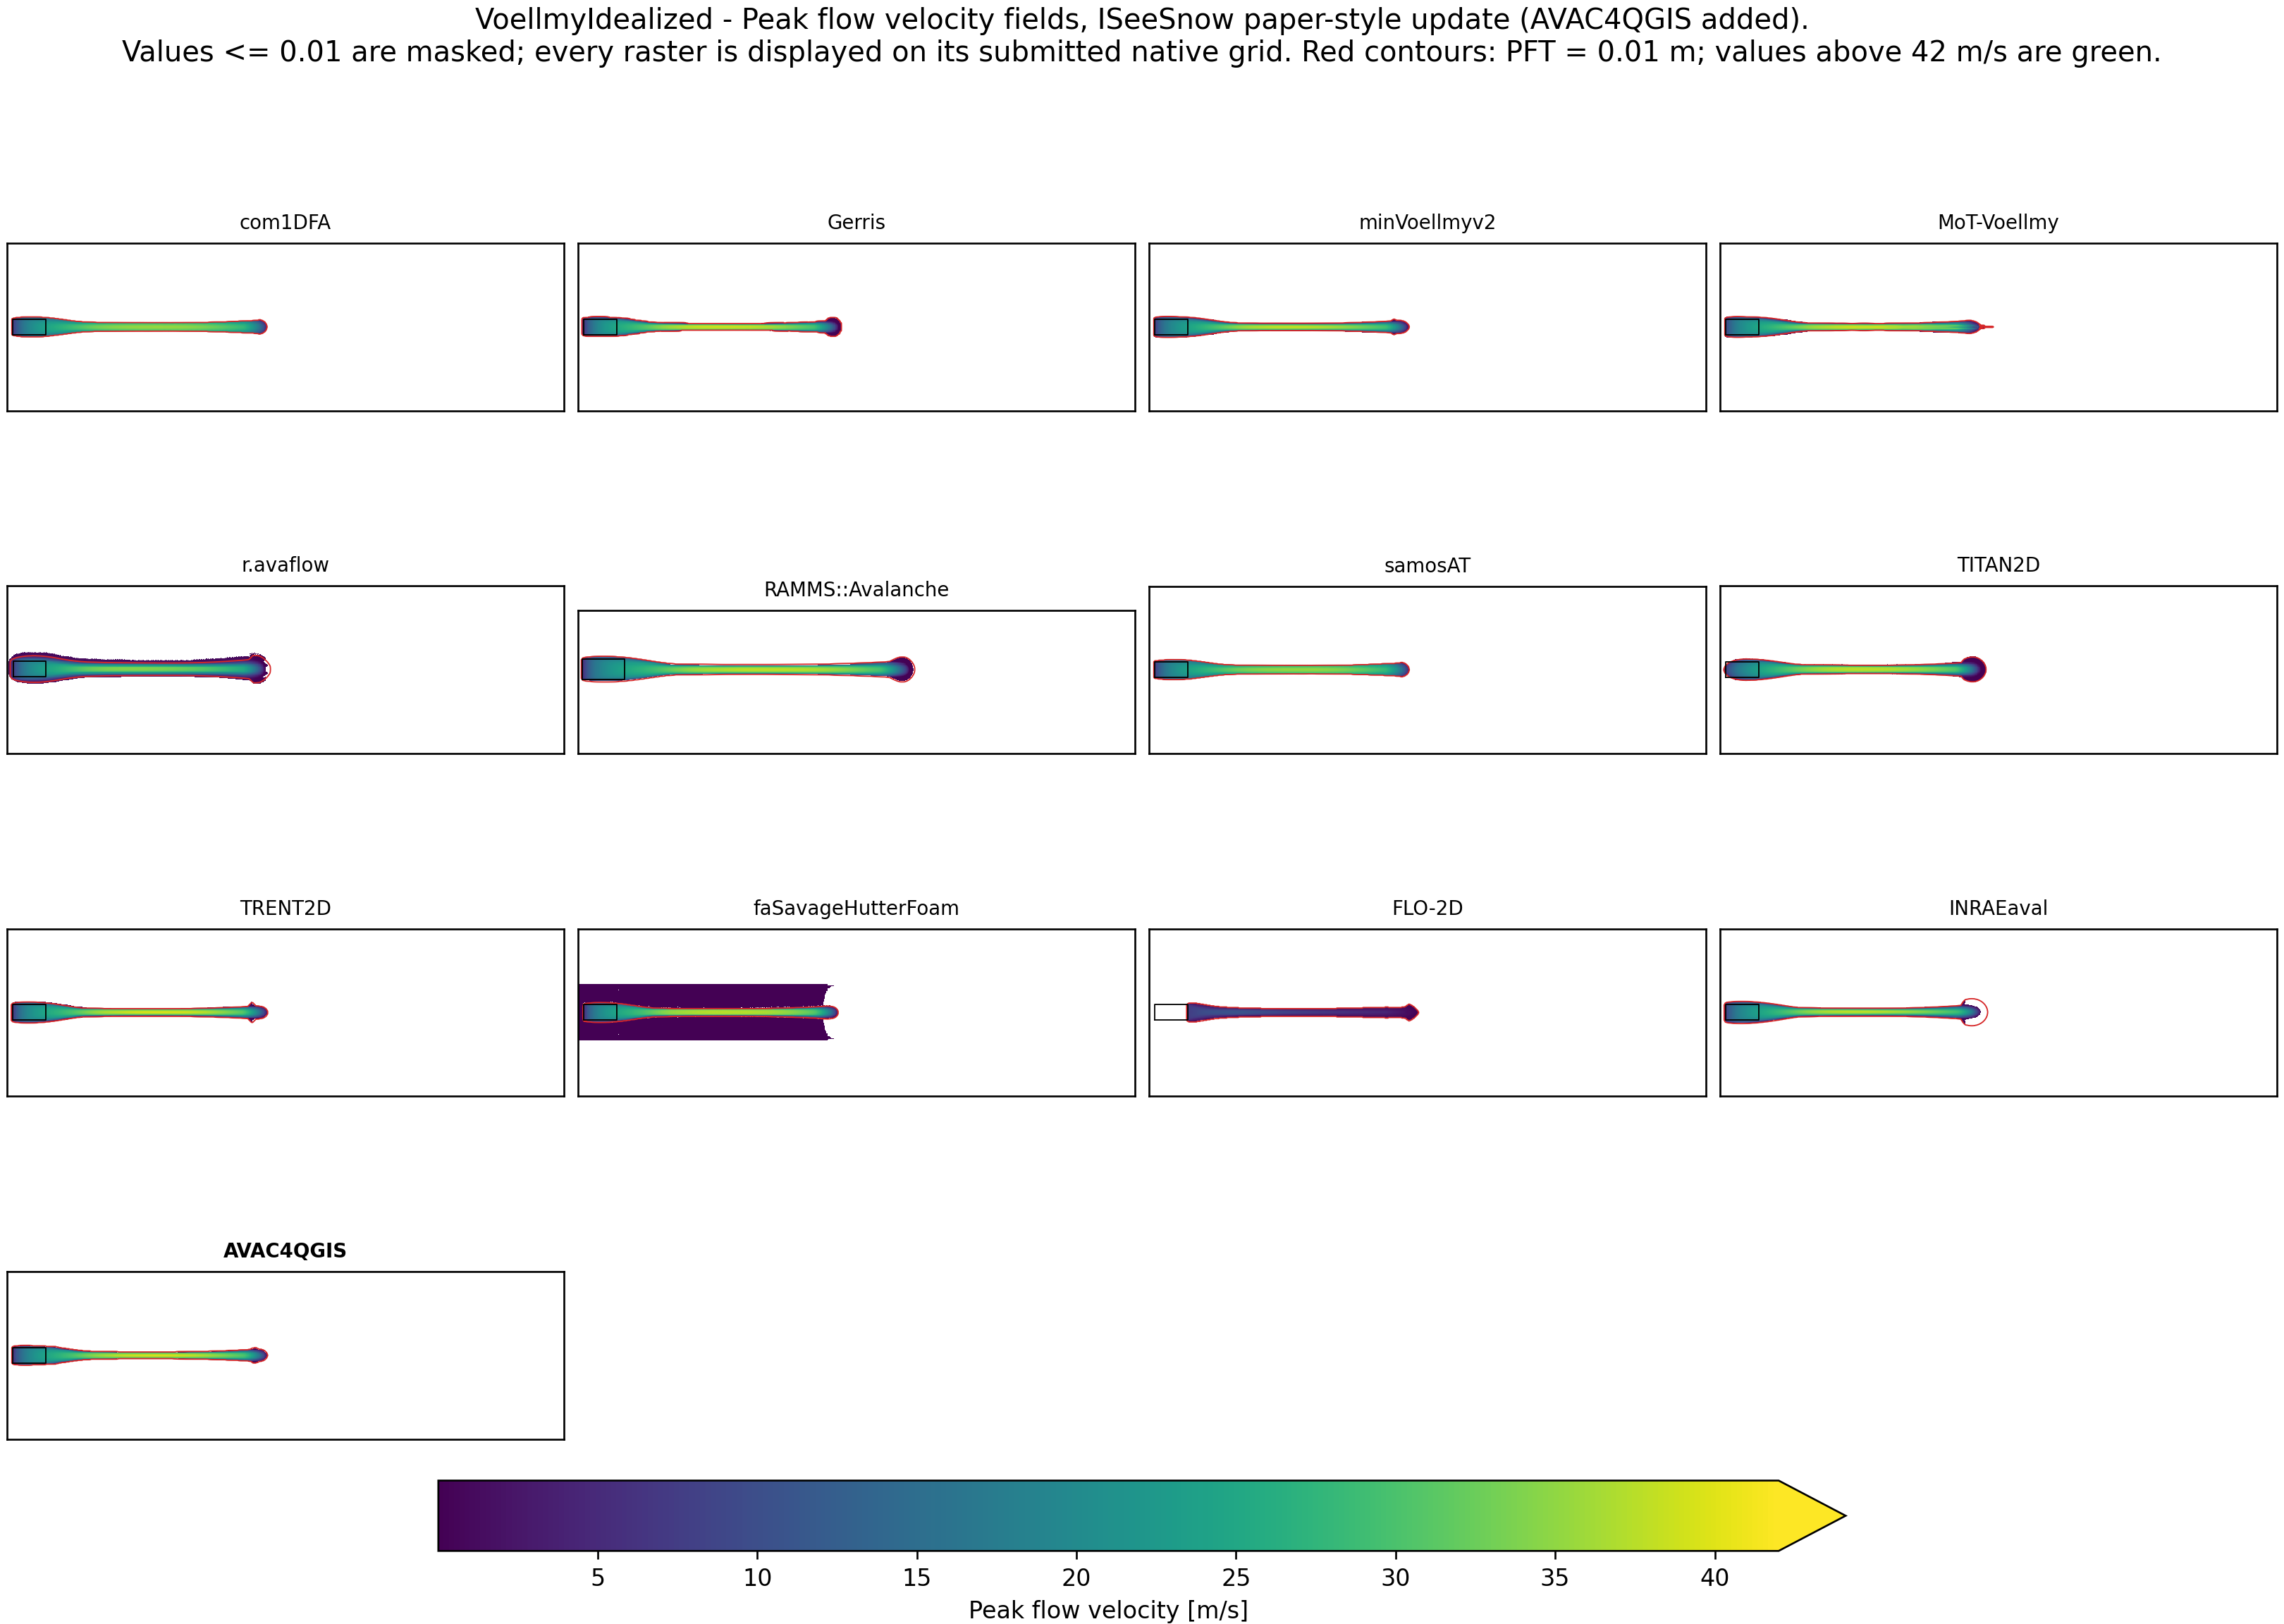

In [7]:
if RESULTS_ROOT == case.path.parent.resolve():
    case.run(case.path.parent / 'reproduce_paper_idealized_voellmy.py', cwd=case.path.parent)
    case.show('../paper_figures/VoellmyIdealized/Figure_2_style_VoellmyIdealized_PFT_with_AVAC4QGIS.png', '../paper_figures/VoellmyIdealized/Figure_3_style_VoellmyIdealized_PFT_0p5m_contours_with_AVAC4QGIS.png', '../paper_figures/VoellmyIdealized/Figure_C2_style_VoellmyIdealized_PFV_with_AVAC4QGIS.png')
else:
    print('Candidate results preserved; publication figures intentionally not replaced.')
